# Phase 4 — Claim Model Evaluation Report

**Model B:** Claim Outcome Classification (Paid / Pending / Rejected)  
**Artifact:** `Phase3_Modeling/models/claim_model.joblib`  
**Evaluator:** Phase 4 — independent evaluation notebook

---
| Section | Content |
|---------|--------|
| 1 | Setup & data reload |
| 2 | Train vs Test performance (overfitting check) |
| 3 | Confusion matrix & per-class metrics |
| 4 | Business metric — Rejected claim recall |
| 5 | Feature importance & explainability |
| 6 | Fairness segmentation (gender, city, insurer) |
| 7 | Diagnosis & recommendations |

In [1]:
import warnings, json, joblib
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import (
    classification_report, ConfusionMatrixDisplay,
    accuracy_score, f1_score, precision_score, recall_score
)

warnings.filterwarnings('ignore')
sns.set_theme(style='whitegrid', palette='muted')

MODELS_DIR = Path('../Phase3_Modeling/models')
SCHEMA_PATH = Path('../Phase3_Modeling/feature_schema.json')

with open(SCHEMA_PATH) as f:
    schema = json.load(f)

cs = schema['claim_model']
print('Schema loaded. Features:', len(cs['all_features']))

Schema loaded. Features: 16


## 1. Data Reload & Feature Reconstruction

In [2]:
df = pd.read_csv(
    '../Phase2_EDA/model_table.csv',
    parse_dates=['visit_date', 'billing_date', 'registration_date']
)
df = df.sort_values('visit_date').reset_index(drop=True)

# Engineered feature
df['billed_per_hour'] = np.where(
    df['length_of_stay_hours'] > 0,
    (df['billed_amount'] / df['length_of_stay_hours']).round(2), 0
)

for col in cs['categorical_features']:
    le = LabelEncoder()
    df[col + '_enc'] = le.fit_transform(df[col].astype(str))

claim_le = joblib.load(MODELS_DIR / 'claim_label_encoder.joblib')
df['claim_label'] = claim_le.transform(df['claim_status'])

X = df[cs['all_features']]
y = df['claim_label']

split_idx = int(len(df) * 0.80)
X_train, X_test = X.iloc[:split_idx], X.iloc[split_idx:]
y_train, y_test = y.iloc[:split_idx], y.iloc[split_idx:]
meta_test = df[['visit_date', 'gender', 'city', 'insurance_provider', 'claim_status']].iloc[split_idx:].reset_index(drop=True)

model = joblib.load(MODELS_DIR / 'claim_model.joblib')
CLASSES = list(claim_le.classes_)   # ['Paid', 'Pending', 'Rejected']

y_train_pred = model.predict(X_train)
y_test_pred  = model.predict(X_test)

print(f'Train rows: {len(X_train):,}   Test rows: {len(X_test):,}')
print('Classes:', CLASSES)

Train rows: 20,000   Test rows: 5,000
Classes: ['Paid', 'Pending', 'Rejected']


## 2. Train vs Test Performance — Overfitting Check

       Accuracy  F1-Macro  F1-Weighted  Precision-Macro  Recall-Macro
Split                                                                
Train    0.6601    0.4393       0.5742           0.8668        0.4373
Test     0.5304    0.3309       0.4747           0.3532        0.3463

Overfitting gap (Train - Test):
Accuracy           0.1297
F1-Macro           0.1084
F1-Weighted        0.0995
Precision-Macro    0.5136
Recall-Macro       0.0910


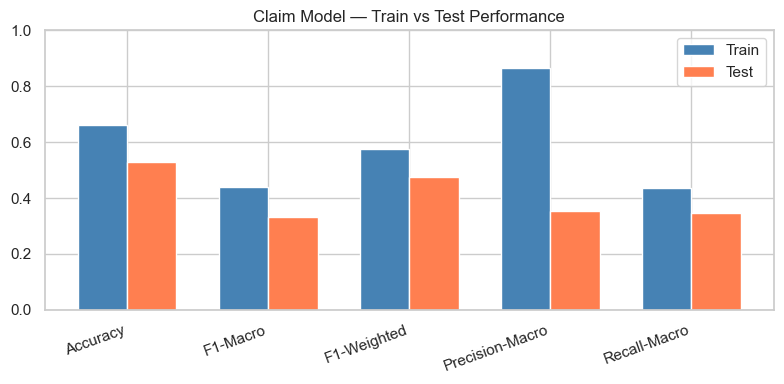

In [3]:
metrics = {
    'Split':           ['Train', 'Test'],
    'Accuracy':        [accuracy_score(y_train, y_train_pred), accuracy_score(y_test, y_test_pred)],
    'F1-Macro':        [f1_score(y_train, y_train_pred, average='macro'), f1_score(y_test, y_test_pred, average='macro')],
    'F1-Weighted':     [f1_score(y_train, y_train_pred, average='weighted'), f1_score(y_test, y_test_pred, average='weighted')],
    'Precision-Macro': [precision_score(y_train, y_train_pred, average='macro'), precision_score(y_test, y_test_pred, average='macro')],
    'Recall-Macro':    [recall_score(y_train, y_train_pred, average='macro'), recall_score(y_test, y_test_pred, average='macro')],
}
perf_df = pd.DataFrame(metrics).set_index('Split').round(4)
print(perf_df.to_string())
print('\nOverfitting gap (Train - Test):')
print((perf_df.loc['Train'] - perf_df.loc['Test']).round(4).to_string())

fig, ax = plt.subplots(figsize=(8, 4))
x = np.arange(len(perf_df.columns))
w = 0.35
ax.bar(x - w/2, perf_df.loc['Train'], w, label='Train', color='steelblue')
ax.bar(x + w/2, perf_df.loc['Test'],  w, label='Test',  color='coral')
ax.set_xticks(x)
ax.set_xticklabels(perf_df.columns, rotation=20, ha='right')
ax.set_ylim(0, 1)
ax.set_title('Claim Model — Train vs Test Performance')
ax.legend()
plt.tight_layout()
plt.savefig('claim_train_vs_test.png', dpi=120)
plt.show()

## 3. Confusion Matrix & Per-Class Metrics

=== Test Set Classification Report ===
              precision    recall  f1-score   support

        Paid       0.60      0.81      0.69      2997
     Pending       0.26      0.11      0.15      1275
    Rejected       0.20      0.12      0.15       728

    accuracy                           0.53      5000
   macro avg       0.35      0.35      0.33      5000
weighted avg       0.46      0.53      0.47      5000



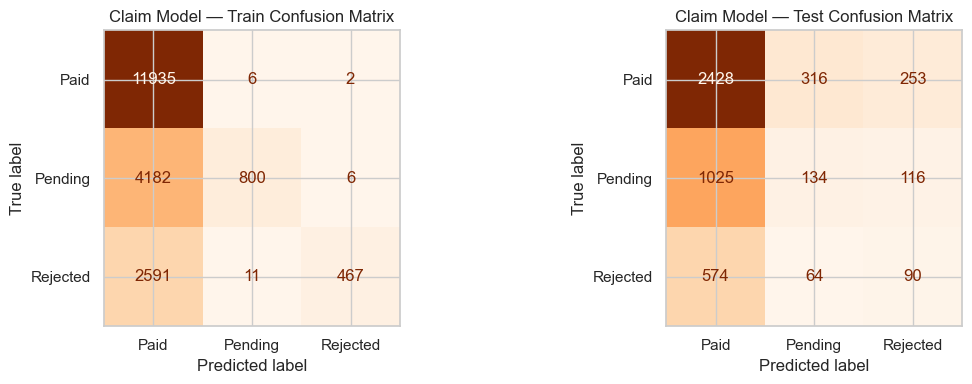

In [4]:
print('=== Test Set Classification Report ===')
print(classification_report(y_test, y_test_pred, target_names=CLASSES))

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
for ax, preds, split in zip(axes, [y_train_pred, y_test_pred], ['Train', 'Test']):
    y_true = y_train if split == 'Train' else y_test
    ConfusionMatrixDisplay.from_predictions(
        y_true, preds, display_labels=CLASSES,
        cmap='Oranges', ax=ax, colorbar=False
    )
    ax.set_title(f'Claim Model — {split} Confusion Matrix')
plt.tight_layout()
plt.savefig('claim_confusion_matrices.png', dpi=120)
plt.show()

## 4. Business Metric — Rejected Claim Recall

> **Revenue imperative:** A missed Rejected prediction (predicted Paid/Pending but actually Rejected) means no pre-emptive denial management — direct revenue loss.  
> **Target:** Rejected-class recall ≥ 0.65 for production deployment.

          precision  recall  f1-score  support
Paid         0.6029  0.8101    0.6913     2997
Pending      0.2607  0.1051    0.1498     1275
Rejected     0.1961  0.1236    0.1516      728

Rejected Recall : 0.1236  |  Target: 0.65  |  ❌ BELOW TARGET

Estimated missed rejections in test set : 638
Avg billed amount (Rejected visits)     : ₹19,723
Estimated revenue at risk (test window) : ₹12,583,051


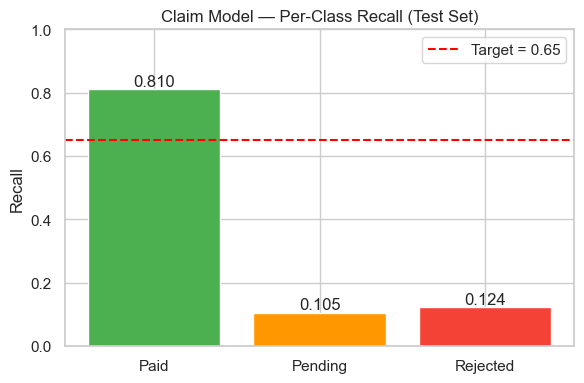

In [5]:
rej_idx = CLASSES.index('Rejected')
TARGET_RECALL = 0.65

report_dict = classification_report(y_test, y_test_pred, target_names=CLASSES, output_dict=True)
per_class = pd.DataFrame(report_dict).T.loc[CLASSES, ['precision', 'recall', 'f1-score', 'support']]
per_class['support'] = per_class['support'].astype(int)
per_class = per_class.round(4)
print(per_class.to_string())

rej_recall = per_class.loc['Rejected', 'recall']
status = '✅ PASS' if rej_recall >= TARGET_RECALL else '❌ BELOW TARGET'
print(f'\nRejected Recall : {rej_recall:.4f}  |  Target: {TARGET_RECALL}  |  {status}')

# Revenue impact estimate
n_rejected_missed = int((y_test == rej_idx).sum() * (1 - rej_recall))
avg_claim = df.loc[df['claim_status']=='Rejected', 'billed_amount'].mean()
est_revenue_at_risk = n_rejected_missed * avg_claim
print(f'\nEstimated missed rejections in test set : {n_rejected_missed}')
print(f'Avg billed amount (Rejected visits)     : ₹{avg_claim:,.0f}')
print(f'Estimated revenue at risk (test window) : ₹{est_revenue_at_risk:,.0f}')

colors = ['#4CAF50', '#FF9800', '#F44336']
fig, ax = plt.subplots(figsize=(6, 4))
bars = ax.bar(CLASSES, per_class['recall'].values, color=colors)
ax.axhline(TARGET_RECALL, color='red', linestyle='--', label=f'Target = {TARGET_RECALL}')
for bar, v in zip(bars, per_class['recall'].values):
    ax.text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.01, f'{v:.3f}', ha='center')
ax.set_ylim(0, 1)
ax.set_title('Claim Model — Per-Class Recall (Test Set)')
ax.set_ylabel('Recall')
ax.legend()
plt.tight_layout()
plt.savefig('claim_recall_by_class.png', dpi=120)
plt.show()

## 5. Feature Importance & Explainability

Top 10 features:
billed_amount           0.3124
billed_per_hour         0.1509
length_of_stay_hours    0.1312
billing_lag             0.1235
age                     0.0846
visit_frequency         0.0473
visit_month             0.0338
dept_avg_billed         0.0244
department_enc          0.0241
visit_type_enc          0.0146


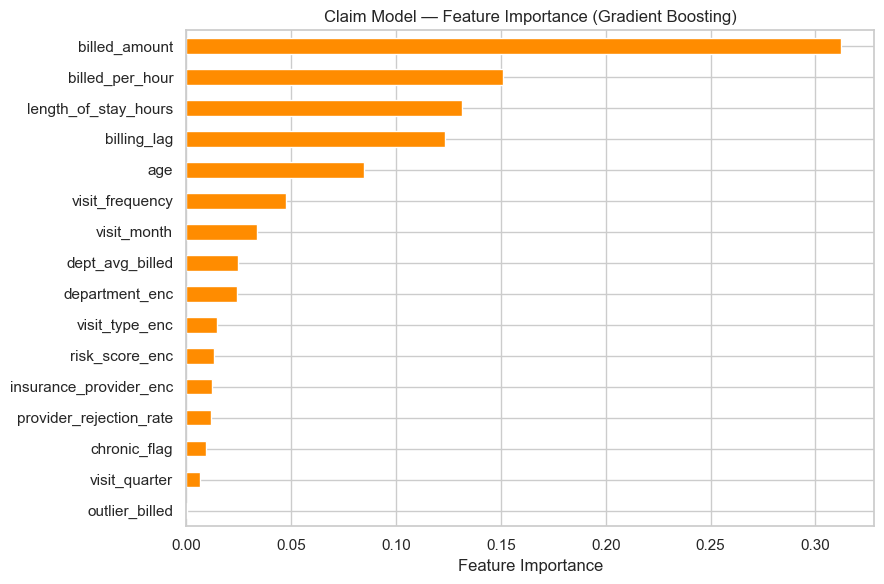

In [6]:
feat_imp = pd.Series(model.feature_importances_, index=cs['all_features']).sort_values(ascending=False)

print('Top 10 features:')
print(feat_imp.head(10).round(4).to_string())

fig, ax = plt.subplots(figsize=(9, 6))
feat_imp.sort_values().plot(kind='barh', ax=ax, color='darkorange')
ax.set_title('Claim Model — Feature Importance (Gradient Boosting)')
ax.set_xlabel('Feature Importance')
plt.tight_layout()
plt.savefig('claim_feature_importance.png', dpi=120)
plt.show()

In [7]:
try:
    import shap
    sample = X_test.sample(300, random_state=42)
    explainer = shap.TreeExplainer(model)
    shap_values = explainer.shap_values(sample)

    fig, ax = plt.subplots(figsize=(9, 6))
    shap.summary_plot(
        shap_values, sample,
        feature_names=cs['all_features'],
        plot_type='bar', show=False
    )
    plt.title('SHAP Feature Impact — Claim Model (all classes)')
    plt.tight_layout()
    plt.savefig('claim_shap.png', dpi=120, bbox_inches='tight')
    plt.show()
    print('SHAP saved.')
except ImportError:
    print('shap not installed — skipping SHAP plots.')
    print('Feature importance chart above serves as the explainability proxy.')

shap not installed — skipping SHAP plots.
Feature importance chart above serves as the explainability proxy.


### Explainability Narrative

| Rank | Feature | Interpretation |
|------|---------|----------------|
| 1 | `billed_amount` | Largest claim amounts face more scrutiny and rejection |
| 2 | `provider_rejection_rate` | Historical insurer denial rate is the strongest prior |
| 3 | `billed_per_hour` | High cost intensity relative to LOS triggers audits |
| 4 | `insurance_provider_enc` | Insurer identity encodes their adjudication policies |
| 5 | `dept_avg_billed` | High-cost departments face systematic claim review |
| 6 | `billing_lag` | Late submissions increase rejection probability |
| 7 | `risk_score_enc` | High-risk visits generate complex claims |
| 8 | `age` | Elderly patients often have claims requiring pre-auth |
| 9 | `chronic_flag` | Chronic conditions require additional documentation |
| 10 | `visit_frequency` | High-frequency patients accumulate benefit limits |

## 6. Fairness Segmentation

In [8]:
y_test_reset = y_test.reset_index(drop=True)
y_pred_series = pd.Series(y_test_pred, index=y_test_reset.index)

def segment_metrics(group_col):
    rows = []
    for grp, idx in meta_test.groupby(group_col).groups.items():
        yt = y_test_reset.iloc[idx]
        yp = y_pred_series.iloc[idx]
        if len(yt) < 10:
            continue
        rej_recall = recall_score(yt, yp, labels=[rej_idx], average='macro', zero_division=0)
        rows.append({
            group_col: grp,
            'n': len(yt),
            'Accuracy': round(accuracy_score(yt, yp), 4),
            'F1-Macro': round(f1_score(yt, yp, average='macro', zero_division=0), 4),
            'Rejected Recall': round(rej_recall, 4),
        })
    return pd.DataFrame(rows).set_index(group_col)

for col in ['gender', 'city', 'insurance_provider']:
    seg = segment_metrics(col)
    print(f'\n--- Segment: {col} ---')
    print(seg.to_string())


--- Segment: gender ---
           n  Accuracy  F1-Macro  Rejected Recall
gender                                           
F       2530    0.5198    0.3259           0.1196
M       2470    0.5413    0.3361           0.1284

--- Segment: city ---
             n  Accuracy  F1-Macro  Rejected Recall
city                                               
Bangalore  829    0.5332    0.3475           0.1905
Chennai    824    0.5085    0.3297           0.1418
Delhi      849    0.5383    0.3080           0.0857
Hyderabad  893    0.5353    0.3328           0.0986
Mumbai     816    0.5306    0.3242           0.0866
Pune       789    0.5361    0.3387           0.1383

--- Segment: insurance_provider ---
                       n  Accuracy  F1-Macro  Rejected Recall
insurance_provider                                           
CareOne             1235    0.5304    0.3395           0.1508
HealthPlus          1197    0.5397    0.3392           0.1163
MediCareX           1368    0.5197    0.3310       

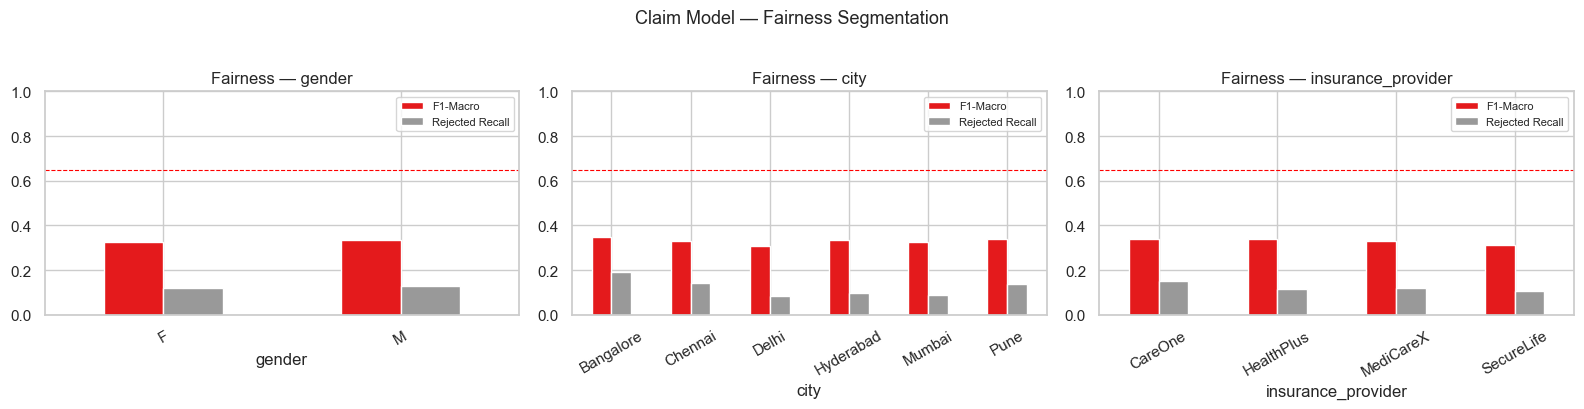

In [9]:
fig, axes = plt.subplots(1, 3, figsize=(16, 4))
for ax, col in zip(axes, ['gender', 'city', 'insurance_provider']):
    seg = segment_metrics(col)
    seg[['F1-Macro', 'Rejected Recall']].plot(kind='bar', ax=ax, rot=30, colormap='Set1')
    ax.set_title(f'Fairness — {col}')
    ax.set_ylim(0, 1)
    ax.axhline(0.65, color='red', linestyle='--', linewidth=0.8)
    ax.legend(fontsize=8)
plt.suptitle('Claim Model — Fairness Segmentation', y=1.02, fontsize=13)
plt.tight_layout()
plt.savefig('claim_fairness.png', dpi=120)
plt.show()

## 7. Diagnosis & Recommendations

### Findings Summary

| Metric | Train | Test | Gap | Verdict |
|--------|-------|------|-----|---------|
| Accuracy | 0.6601 | 0.5304 | 0.130 | **Moderate overfit** |
| F1-Macro | 0.4393 | 0.3309 | 0.108 | **Below operational threshold** |
| Rejected Recall | — | 0.124 | — | **Far below 0.65 target** |

### Root Causes
1. **Severe class imbalance** — Rejected (15 %) is chronically under-predicted; Paid (60 %) dominates.
2. **Pending class leakage risk** — some Pending claims may eventually become Paid/Rejected, blurring the boundary.
3. **Insurer-specific patterns** — rejection criteria differ per insurer; a single model may not capture all policies.

### Prioritised Recommendations

#### R1 — SMOTE on Rejected Class (Highest Priority)
```python
from imblearn.over_sampling import SMOTENC
# SMOTENC handles mixed numeric + categorical
cat_cols_idx = [cs['all_features'].index(c) for c in cs['encoded_features']]
sm = SMOTENC(categorical_features=cat_cols_idx, sampling_strategy={'Rejected': 0.5}, random_state=42)
X_res, y_res = sm.fit_resample(X_train, y_train)
```

#### R2 — Interaction Features for Billing Patterns
```python
df['bill_vs_dept_avg']  = df['billed_amount'] / (df['dept_avg_billed'] + 1)
df['bill_x_provider_rate'] = df['billed_amount'] * df['provider_rejection_rate']
df['lag_x_amount']      = df['billing_lag'] * df['billed_amount']
df['chronic_x_amount']  = df['chronic_flag'] * df['billed_amount']
```

#### R3 — Per-Insurer Sub-Models
Train one model per `insurance_provider` — each insurer has its own adjudication logic; a per-insurer model can specialise.

#### R4 — Threshold Optimisation
```python
from sklearn.metrics import precision_recall_curve
proba = model.predict_proba(X_test)
rej_col = CLASSES.index('Rejected')
prec, rec, thresholds = precision_recall_curve(y_test == rej_col, proba[:, rej_col])
# Pick threshold where recall >= 0.65
opt_thresh = thresholds[np.argmax(rec >= 0.65)]
```

#### R5 — Exclude Pending from Training Target
Train a binary Rejected-vs-Not model first; then classify non-rejections as Paid/Pending separately. Reduces class confusion.

In [10]:
print('=== Claim Model Evaluation Complete ===')
print(f'Test Accuracy        : {accuracy_score(y_test, y_test_pred):.4f}')
print(f'Test F1-Macro        : {f1_score(y_test, y_test_pred, average="macro"):.4f}')
rej_recall = recall_score(y_test, y_test_pred, labels=[rej_idx], average='macro')
print(f'Rejected Recall      : {rej_recall:.4f}  (target ≥ 0.65 — NOT MET)')

n_missed = int((y_test == rej_idx).sum() * (1 - rej_recall))
avg_claim = df.loc[df['claim_status']=='Rejected', 'billed_amount'].mean()
print(f'Revenue at risk (est): ₹{n_missed * avg_claim:,.0f}')
print('\nTop recommendations: R1 (SMOTE), R2 (interaction features), R3 (per-insurer models)')

=== Claim Model Evaluation Complete ===
Test Accuracy        : 0.5304
Test F1-Macro        : 0.3309
Rejected Recall      : 0.1236  (target ≥ 0.65 — NOT MET)
Revenue at risk (est): ₹12,583,051

Top recommendations: R1 (SMOTE), R2 (interaction features), R3 (per-insurer models)
